# NYC Taxi: Clustering and Classification

## 1. EDA & Preprocessing
- Load data
- Feature types (categorical vs numeric)
- Distribution & imbalance

In [1]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load
df = pd.read_csv('../data/raw/yellow_tripdata_2025-09.csv')
print("data size:", df.shape)
df.head()

/var/folders/cy/h4rtzttd0b95fwnjhlv7y8lw0000gn/T/ipykernel_78189/2177304129.py:2: DtypeWarning: Columns (3,5,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/raw/yellow_tripdata_2025-09.csv')


data size: (4251015, 20)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2025-09-11 12:26:19.000000,2025-09-11 12:56:08.000000,1,2.67,1,N,142,140,1,25.4,0.0,0.5,6.03,0.0,1.0,36.18,2.5,0.0,0.75
1,2,2025-09-11 12:09:54.000000,2025-09-11 12:48:25.000000,2,1.27,1,N,186,163,1,30.3,0.0,0.5,5.26,0.0,1.0,40.31,2.5,0.0,0.75
2,1,2025-09-11 12:51:50.000000,2025-09-11 14:17:45.000000,1,26.20,99,N,86,26,1,72.5,0.0,0.5,0.00,0.0,0.0,73.00,0.0,0.0,0.00
3,1,2025-09-11 12:27:37.000000,2025-09-11 12:31:27.000000,1,0.40,1,N,141,140,1,5.1,2.5,0.5,2.00,0.0,1.0,11.10,2.5,0.0,0.00
4,1,2025-09-11 12:36:09.000000,2025-09-11 12:51:53.000000,2,1.10,1,N,140,237,1,13.5,2.5,0.5,1.75,0.0,1.0,19.25,2.5,0.0,0.00


In [7]:
# 3. 기본 정보 확인
print("Info")
df.info()

print("\nMissing values (columns with NaN):")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nDuplicated rows:", df.duplicated().sum())


Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4251015 entries, 0 to 4251014
Data columns (total 20 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        object 
 4   trip_distance          float64
 5   RatecodeID             object 
 6   store_and_fwd_flag     object 
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           int64  
 10  fare_amount            float64
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             float64
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           float64
 17  congestion_surcharge   object 
 18  Airport_fee            object 
 19  cbd_congestion_fee     float64
dtypes: float64(9), int64(4), object(7)
memory usage: 648.7+ MB

Missing values (columns w

In [8]:
# 4. 통계 요약 (수치형)
print("Numeric Description")
display(df.describe())


Numeric Description


,VendorID,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,cbd_congestion_fee
count,4.251015e+06,4.251015e+06,4.251015e+06,4.251015e+06,4.251015e+06,4.251015e+06,4.251015e+06,4.251015e+06,4.251015e+06,4.251015e+06,4.251015e+06,4.251015e+06,4.251015e+06
mean,1.876918e+00,6.839378e+00,1.609733e+02,1.608512e+02,9.254954e-01,1.920400e+01,1.131808e+00,4.749536e-01,2.857928e+00,5.180932e-01,9.422438e-01,2.771327e+01,5.343283e-01
std,7.215712e-01,6.608708e+02,6.655376e+01,7.078625e+01,7.661095e-01,1.582837e+02,1.809446e+00,1.438204e-01,4.048930e+00,2.165274e+00,3.018697e-01,1.588736e+02,3.592184e-01
min,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-9.980000e+02,-7.500000e+00,-5.000000e-01,-8.855000e+01,-1.090600e+02,-1.000000e+00,-1.002250e+03,-7.500000e-01
25%,2.000000e+00,1.070000e+00,1.140000e+02,1.070000e+02,0.000000e+00,9.300000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.632000e+01,0.000000e+00
50%,2.000000e+00,1.920000e+00,1.610000e+02,1.620000e+02,1.000000e+00,1.490000e+01,0.000000e+00,5.000000e-01,2.000000e+00,0.000000e+00,1.000000e+00,2.215000e+01,7.500000e-01
75%,2.000000e+00,3.930000e+00,2.320000e+02,2.330000e+02,1.000000e+00,2.400000e+01,2.500000e+00,5.000000e-01,4.000000e+00,0.000000e+00,1.000000e+00,3.182000e+01,7.500000e-01
max,7.000000e+00,3.186086e+05,2.650000e+02,2.650000e+02,4.000000e+00,3.238003e+05,3.861000e+01,1.050000e+01,4.000000e+02,1.340600e+02,1.000000e+00,3.238202e+05,1.750000e+00


In [9]:
# 5. target 및 feature 후보 확인
target_col = 'payment_type'  # Task B의 supervised target

# 변수 분류
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Numeric Features:", num_cols)
print("Categorical Features:", cat_cols)


Numeric Features: ['VendorID', 'trip_distance', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'cbd_congestion_fee']
Categorical Features: ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'RatecodeID', 'store_and_fwd_flag', 'congestion_surcharge', 'Airport_fee']


/var/folders/cy/h4rtzttd0b95fwnjhlv7y8lw0000gn/T/ipykernel_78189/2131940568.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='payment_type', data=df, palette='Set2')


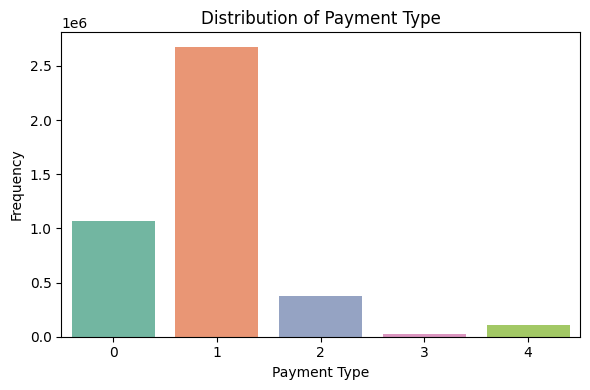

In [6]:
# 6. payment_type 분포 시각화
plt.figure(figsize=(6,4))
sns.countplot(x='payment_type', data=df, palette='Set2')
plt.title("Distribution of Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## 2. Task A: Clustering
- Feature selection
- Distance metric justification
- Encoding & Scaling
- Clustering results
- Cluster evaluation (silhouette)
- Cluster interpretation

## 3. Task B: Supervised Learning
- Model reuse
- Metrics: Accuracy, F1, Confusion Matrix
- Class imbalance handling

## 4. Task C: Clustering vs Classification
- Label mapping from clusters
- Performance comparison
- Discussion


## 5. Final Conclusions & Reflection